In [5]:
!pip install torch torchvision torchaudio
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install matplotlib

from pathlib import Path
import matplotlib.pyplot as plt
import torch
from robustbench import load_model

  Cloning https://github.com/RobustBench/robustbench.git to /private/var/folders/7x/0pnrdfvn0ts5vvq0s97bwpl80000gn/T/pip-req-build-p04vahjl
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /private/var/folders/7x/0pnrdfvn0ts5vvq0s97bwpl80000gn/T/pip-req-build-p04vahjl
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /private/var/folders/7x/0pnrdfvn0ts5vvq0s97bwpl80000gn/T/pip-install-_nxmofqk/autoattack_e8d54ea474b64a18aa67f808b2c61d5f
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /private/var/folders/7x/0pnrdfvn0ts5vvq0s97bwpl80000gn/T/pip-install-_nxmofqk/autoattack_e8d54ea474b64a18aa

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
#Change this list for other models and perturbation files
experiment_configs = [
    {
        "id": "cifar10_standard",
        "label": "Standard",
        "model_name": "Standard",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "perturbation_file": Path("saved_outputs") / "perturbations" / "cifar10_standard_linf_eps8_adv.pt",
    },
    {
        "id": "cifar10_engstrom",
        "label": "Robust (Engstrom)",
        "model_name": "Engstrom2019Robustness",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "perturbation_file": Path("saved_outputs") / "perturbations" / "cifar10_engstrom_linf_eps8_adv.pt",
    },
]

loaded_models = {}
for config in experiment_configs:
    experiment_id = config["id"]
    print(f"Loading model: {experiment_id}")
    model = load_model(
        model_name=config["model_name"],
        dataset=config["dataset"],
        threat_model=config["threat_model"],
    ).to(device)
    model.eval()
    loaded_models[experiment_id] = model

print("Loaded models:", list(loaded_models.keys()))

Loading model: cifar10_standard
Loading model: cifar10_engstrom
Loaded models: ['cifar10_standard', 'cifar10_engstrom']


In [ ]:
#Load saved adversarial examples and perturbations from the files in experiment_configs
def torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)


def load_saved_attack(config):
    experiment_id = config["id"]
    attack_path = Path(config["perturbation_file"])
    if not attack_path.exists():
        raise FileNotFoundError(f"Missing perturbation file for {experiment_id}: {attack_path}")

    data = torch_load(attack_path)
    if not isinstance(data, dict):
        raise TypeError(f"Expected {attack_path} to contain a dict, got {type(data).__name__}")

    required = {"clean_images", "clean_labels", "adv_images"}
    missing = required.difference(data.keys())
    if missing:
        raise KeyError(f"{attack_path} is missing required keys: {sorted(missing)}")

    data["clean_images"] = data["clean_images"].to(device)
    data["clean_labels"] = data["clean_labels"].to(device)
    data["adv_images"] = data["adv_images"].to(device)

    if "perturbations" in data:
        data["perturbations"] = data["perturbations"].to(device)
    else:
        data["perturbations"] = data["adv_images"] - data["clean_images"]
        print(f"{experiment_id}: recomputed perturbations from adv_images - clean_images")

    if data["perturbations"].shape != data["adv_images"].shape:
        raise ValueError(
            f"{attack_path} has perturbations shape {tuple(data['perturbations'].shape)} "
            f"but adv_images shape {tuple(data['adv_images'].shape)}"
        )

    if not torch.allclose(data["perturbations"], data["adv_images"] - data["clean_images"], atol=1e-6):
        print(f"Warning: stored perturbations in {attack_path} do not exactly match adv_images - clean_images")

    data["path"] = attack_path
    data["config"] = config
    return data


loaded_attacks = [load_saved_attack(config) for config in experiment_configs]
attack_by_id = {attack["config"]["id"]: attack for attack in loaded_attacks}

#Use the first configured experiment as the reference batch 
#for comparing clean images and labels across all loaded attacks
reference_attack = loaded_attacks[0]
clean_images = reference_attack["clean_images"]
clean_labels = reference_attack["clean_labels"]
adv_images = reference_attack["adv_images"]
perturbations = reference_attack["perturbations"]

same_clean_batch = all(
    torch.equal(reference_attack["clean_images"], attack["clean_images"])
    and torch.equal(reference_attack["clean_labels"], attack["clean_labels"])
    for attack in loaded_attacks[1:]
)
if same_clean_batch:
    print("All perturbation files use the same clean batch.")
else:
    print("Warning: not all perturbation files use the same clean batch/labels.")

for attack in loaded_attacks:
    config = attack["config"]
    print(f"\nLoaded {config['label']} ({config['id']}) from {attack['path']}")
    print("Clean images:", tuple(attack["clean_images"].shape))
    print("Adversarial images:", tuple(attack["adv_images"].shape))
    print("Perturbations:", tuple(attack["perturbations"].shape))
    print("Epsilon:", attack.get("epsilon", "unknown"))

All perturbation files use the same clean batch.

Loaded Standard (cifar10_standard) from saved_outputs/perturbations/cifar10_standard_linf_eps8_adv.pt
Clean images: (8, 3, 32, 32)
Adversarial images: (8, 3, 32, 32)
Perturbations: (8, 3, 32, 32)
Epsilon: 0.03137254901960784

Loaded Robust (Engstrom) (cifar10_engstrom) from saved_outputs/perturbations/cifar10_engstrom_linf_eps8_adv.pt
Clean images: (8, 3, 32, 32)
Adversarial images: (8, 3, 32, 32)
Perturbations: (8, 3, 32, 32)
Epsilon: 0.03137254901960784


Standard loaded perturbations | clean correct: 8/8 | successful attacks: 8/8 | ASR: 100.0%
Robust (Engstrom) loaded perturbations | clean correct: 8/8 | successful attacks: 5/8 | ASR: 62.5%


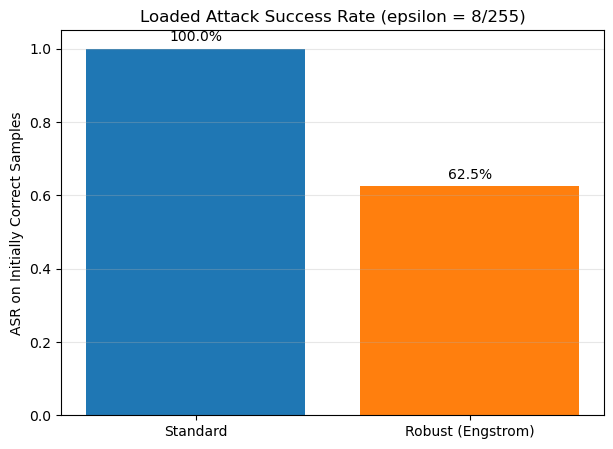

In [ ]:
#Compute ASR from the loaded adversarial images
def epsilon_value(attack_data, default=8 / 255):
    value = attack_data.get("epsilon", default)
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def evaluate_loaded_attack(model, attack_data):
    clean_x = attack_data["clean_images"]
    labels = attack_data["clean_labels"]
    adv_x = attack_data["adv_images"]

    with torch.no_grad():
        clean_pred = model(clean_x).argmax(dim=1)
        adv_pred = model(adv_x).argmax(dim=1)

    initially_correct = clean_pred == labels
    attack_success = initially_correct & (adv_pred != labels)

    clean_correct = int(initially_correct.sum().item())
    successes = int(attack_success.sum().item())
    asr = successes / clean_correct if clean_correct else 0.0
    robust_accuracy = float((adv_pred == labels).float().mean().item())

    return {
        "asr": asr,
        "successes": successes,
        "clean_correct": clean_correct,
        "total": int(labels.numel()),
        "robust_accuracy": robust_accuracy,
        "clean_pred": clean_pred,
        "adv_pred": adv_pred,
    }


analysis_results = []
for attack in loaded_attacks:
    config = attack["config"]
    result = evaluate_loaded_attack(loaded_models[config["id"]], attack)
    result["config"] = config
    result["attack"] = attack
    analysis_results.append(result)
    print(
        f"{config['label']} loaded perturbations | "
        f"clean correct: {result['clean_correct']}/{result['total']} | "
        f"successful attacks: {result['successes']}/{result['clean_correct']} | "
        f"ASR: {result['asr'] * 100:.1f}%"
    )

x_labels = [result["config"]["label"] for result in analysis_results]
asr_values = [result["asr"] for result in analysis_results]
eps_values = sorted({round(epsilon_value(result["attack"]) * 255, 4) for result in analysis_results})
eps_label = f"{eps_values[0]:g}/255" if len(eps_values) == 1 else "mixed epsilons"
colors = [plt.cm.tab10(i % 10) for i in range(len(asr_values))]

plt.figure(figsize=(max(7, len(asr_values) * 2.5), 5))
bars = plt.bar(x_labels, asr_values, color=colors)
for bar, value in zip(bars, asr_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value * 100:.1f}%", ha="center")

plt.title(f"Loaded Attack Success Rate (epsilon = {eps_label})")
plt.ylabel("ASR on Initially Correct Samples")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

Visualizing loaded perturbations for Standard:


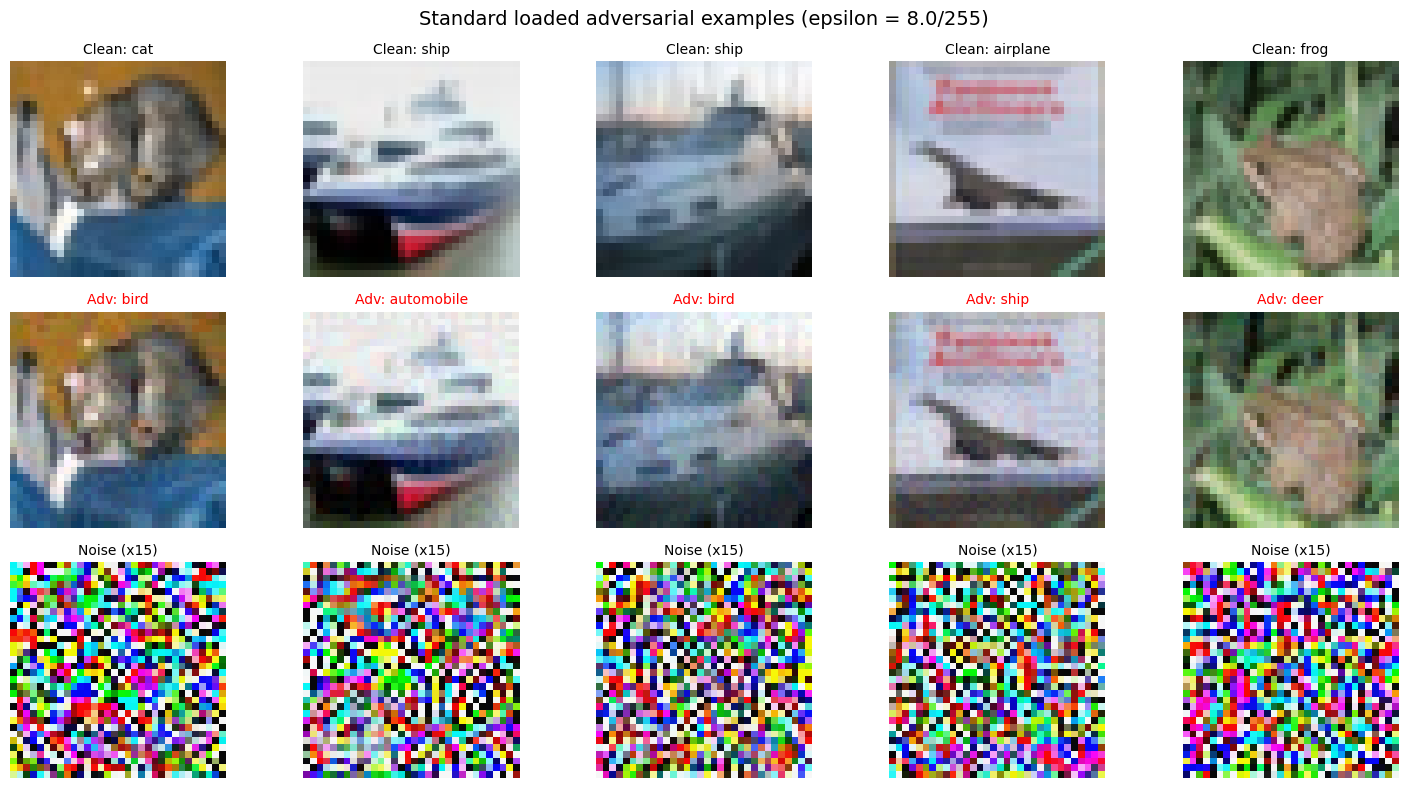

Visualizing loaded perturbations for Robust (Engstrom):


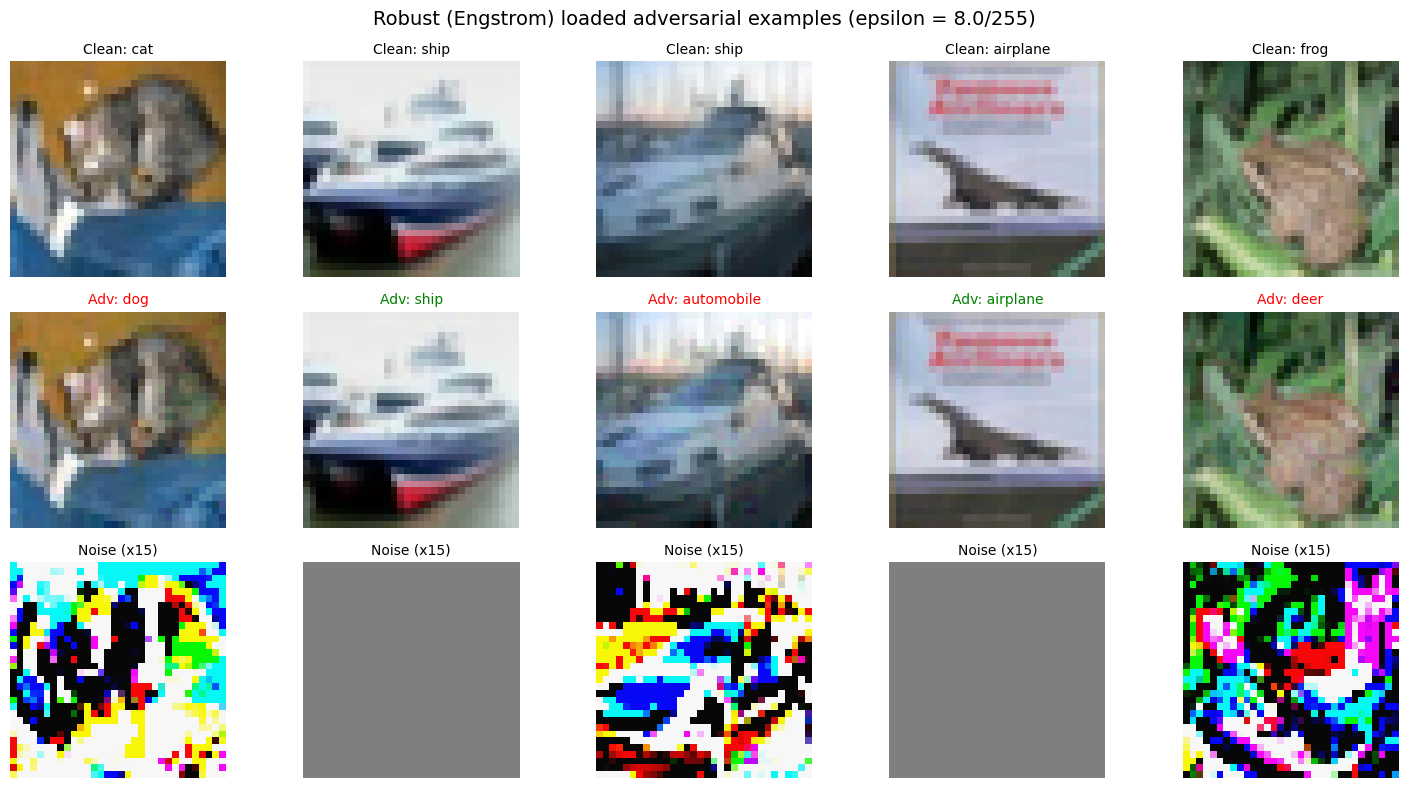

In [10]:
def visualize_loaded_adversarial_examples(model, attack_data, title=None, n_display=5, noise_scale=15):
    config = attack_data.get("config", {})
    title = title or config.get("label", config.get("id", "Model"))
    n_display = min(n_display, attack_data["clean_images"].shape[0])
    images_to_show = attack_data["clean_images"][:n_display]
    labels_to_show = attack_data["clean_labels"][:n_display]
    adv_images = attack_data["adv_images"][:n_display]
    perturbations = attack_data["perturbations"][:n_display]

    amplified_noise = torch.clamp(perturbations * noise_scale + 0.5, 0, 1)

    def to_np(t):
        return t.permute(1, 2, 0).detach().cpu().numpy()

    fig, axes = plt.subplots(3, n_display, figsize=(n_display * 3, 8), squeeze=False)
    classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

    for i in range(n_display):
        label_idx = int(labels_to_show[i].item())

        axes[0, i].imshow(to_np(images_to_show[i]))
        axes[0, i].set_title(f"Clean: {classes[label_idx]}", fontsize=10)
        axes[0, i].axis("off")

        axes[1, i].imshow(to_np(adv_images[i]))
        with torch.no_grad():
            pred = int(model(adv_images[i].unsqueeze(0)).argmax(dim=1).item())
        color = "red" if pred != label_idx else "green"
        axes[1, i].set_title(f"Adv: {classes[pred]}", fontsize=10, color=color)
        axes[1, i].axis("off")

        axes[2, i].imshow(to_np(amplified_noise[i]))
        axes[2, i].set_title(f"Noise (x{noise_scale})", fontsize=10)
        axes[2, i].axis("off")

    eps = epsilon_value(attack_data)
    plt.suptitle(f"{title} loaded adversarial examples (epsilon = {eps * 255:.1f}/255)", fontsize=14)
    plt.tight_layout()
    plt.show()


for attack in loaded_attacks:
    config = attack["config"]
    print(f"Visualizing loaded perturbations for {config['label']}:")
    visualize_loaded_adversarial_examples(loaded_models[config["id"]], attack)

In the visualization above, titles are color-coded to indicate model behavior on the loaded adversarial examples. Red titles mark successful attacks where the saved perturbation changed the prediction; green titles mark examples where the prediction stayed correct.